In [2]:
# 정형 데이터(전자상거래 거래) 불러오기 및 결합
import pandas as pd
from pathlib import Path

STRUCTURED_DATA_DIR = Path("/Users/junyup/Desktop/workspace/SafeTrader_Detection/datasets/Fraudulent_E-Commerce_Transaction_Data")

file_names = ["Fraudulent_E-Commerce_Transaction_Data.csv", "Fraudulent_E-Commerce_Transaction_Data_2.csv"]

dfs = []
for file_name in file_names:
    temp = pd.read_csv(STRUCTURED_DATA_DIR / file_name)
    temp["source_file"] = file_name
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head()

(1496586, 17)


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour,source_file
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5,Fraudulent_E-Commerce_Transaction_Data.csv
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8,Fraudulent_E-Commerce_Transaction_Data.csv
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3,Fraudulent_E-Commerce_Transaction_Data.csv
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20,Fraudulent_E-Commerce_Transaction_Data.csv
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5,Fraudulent_E-Commerce_Transaction_Data.csv


In [3]:
# 기초 정보 확인
df.info()
df["Is Fraudulent"].value_counts()
df["source_file"].value_counts()

# 결측치 확인
print(f"\n결측치 수:\n{df.isnull().sum()}")

# 중복값 확인
print()
print("전체 중복 행 수:", df.duplicated().sum())
print("Transaction ID 기준 중복 수:", df.duplicated(subset=["Transaction ID"]).sum())

<class 'pandas.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1496586 non-null  str    
 1   Customer ID         1496586 non-null  str    
 2   Transaction Amount  1496586 non-null  float64
 3   Transaction Date    1496586 non-null  str    
 4   Payment Method      1496586 non-null  str    
 5   Product Category    1496586 non-null  str    
 6   Quantity            1496586 non-null  int64  
 7   Customer Age        1496586 non-null  int64  
 8   Customer Location   1496586 non-null  str    
 9   Device Used         1496586 non-null  str    
 10  IP Address          1496586 non-null  str    
 11  Shipping Address    1496586 non-null  str    
 12  Billing Address     1496586 non-null  str    
 13  Is Fraudulent       1496586 non-null  int64  
 14  Account Age Days    1496586 non-null  int64  
 15  Transaction Hour    149658

In [4]:
# 고유값이 적은 컬럼들은 category 타입으로 변환 (메모리 최적화) - Payment Method, Device Used 제거로 목록 수정
df["Product Category"] = df["Product Category"].astype("category")
df["source_file"] = df["source_file"].astype("category")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Transaction ID      1496586 non-null  str     
 1   Customer ID         1496586 non-null  str     
 2   Transaction Amount  1496586 non-null  float64 
 3   Transaction Date    1496586 non-null  str     
 4   Payment Method      1496586 non-null  str     
 5   Product Category    1496586 non-null  category
 6   Quantity            1496586 non-null  int64   
 7   Customer Age        1496586 non-null  int64   
 8   Customer Location   1496586 non-null  str     
 9   Device Used         1496586 non-null  str     
 10  IP Address          1496586 non-null  str     
 11  Shipping Address    1496586 non-null  str     
 12  Billing Address     1496586 non-null  str     
 13  Is Fraudulent       1496586 non-null  int64   
 14  Account Age Days    1496586 non-null  int64   
 15  Transacti

In [5]:
# 판매자 사기 탐지가 목적이나 판매자 데이터가 없어 구매자 데이터로 대체 분석 중
# OfferUp 등에서 확인 불가능한 피처 + 사전 예측에 못 쓰는 사후 정보(Payment Method, Transaction Hour) 제거
drop_cols = [
    "Payment Method", "Customer Location", "Device Used",
    "IP Address", "Billing Address", "Transaction Hour",
]
df = df.drop(columns=drop_cols)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Transaction ID      1496586 non-null  str     
 1   Customer ID         1496586 non-null  str     
 2   Transaction Amount  1496586 non-null  float64 
 3   Transaction Date    1496586 non-null  str     
 4   Product Category    1496586 non-null  category
 5   Quantity            1496586 non-null  int64   
 6   Customer Age        1496586 non-null  int64   
 7   Shipping Address    1496586 non-null  str     
 8   Is Fraudulent       1496586 non-null  int64   
 9   Account Age Days    1496586 non-null  int64   
 10  source_file         1496586 non-null  category
dtypes: category(2), float64(1), int64(4), str(4)
memory usage: 105.6 MB


In [6]:
# Transaction Date를 datetime으로 변환
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

# 범주형 컬럼들의 고유값 개수 확인 (category 변환 대상 판단)
categorical_candidates = ["Product Category", "source_file"]
for col in categorical_candidates:
    print(f"{col}: {df[col].nunique()}개 고유값")

Product Category: 5개 고유값
source_file: 2개 고유값


In [7]:
# 타겟(Is Fraudulent) 분포 확인
target_counts = df["Is Fraudulent"].value_counts()
target_ratio = df["Is Fraudulent"].value_counts(normalize=True) * 100

pd.DataFrame({"count": target_counts, "ratio(%)": target_ratio.round(2)})

# source_file별 타겟 비율도 확인 (두 파일을 합쳤으니 비율 차이가 있는지 체크)
df.groupby("source_file")["Is Fraudulent"].value_counts(normalize=True).mul(100).round(2).unstack()

Is Fraudulent,0,1
source_file,,
Fraudulent_E-Commerce_Transaction_Data.csv,94.99,5.01
Fraudulent_E-Commerce_Transaction_Data_2.csv,94.83,5.17


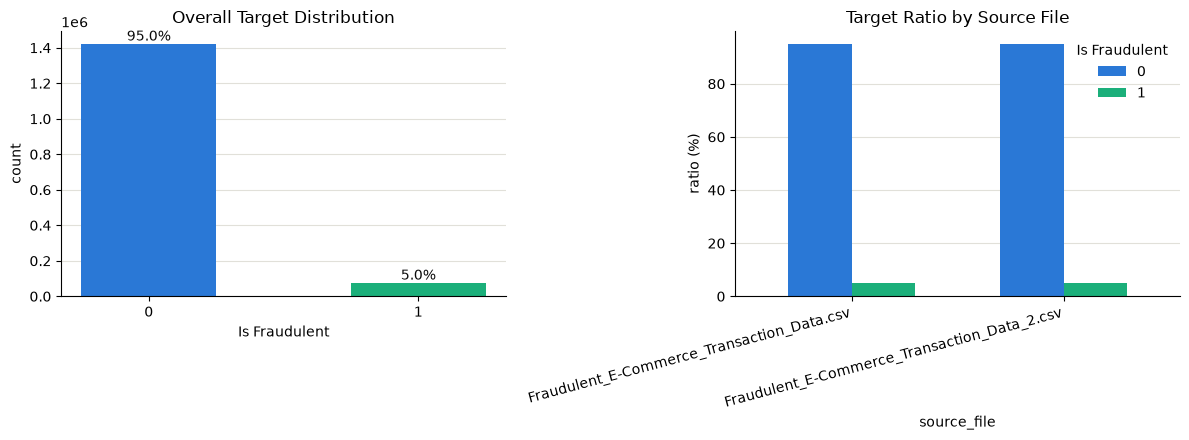

In [8]:
# 타겟(Is Fraudulent) 분포 시각화
import matplotlib.pyplot as plt

target_counts = df["Is Fraudulent"].value_counts().sort_index()
target_pct = df["Is Fraudulent"].value_counts(normalize=True).sort_index() * 100

colors = ["#2a78d6", "#1baf7a"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(target_counts.index.astype(str), target_counts.values, color=colors, width=0.5)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, color="#0b0b0b")
axes[0].set_title("Overall Target Distribution")
axes[0].set_xlabel("Is Fraudulent")
axes[0].set_ylabel("count")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
axes[0].set_axisbelow(True)

source_target_pct = df.groupby("source_file")["Is Fraudulent"].value_counts(normalize=True).mul(100).unstack()
source_target_pct.plot(kind="bar", ax=axes[1], color=colors, width=0.6)
axes[1].set_title("Target Ratio by Source File")
axes[1].set_xlabel("source_file")
axes[1].set_ylabel("ratio (%)")
axes[1].legend(title="Is Fraudulent", frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
axes[1].set_axisbelow(True)
plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

Q1. 불균형 데이터: 어떻게 해결할 것 인가?
- 후보 1. class_weight='balanced'
- 후보 2. SMOTE

In [9]:
# 수치형 변수 기초 통계 확인
numeric_cols = ["Transaction Amount", "Quantity", "Customer Age", "Account Age Days"]
df[numeric_cols].describe()

,Transaction Amount,Quantity,Customer Age,Account Age Days
count,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06
mean,2.268093e+02,3.000235e+00,3.451284e+01,1.796308e+02
std,2.705831e+02,1.414814e+00,1.000323e+01,1.068726e+02
min,1.000000e+01,1.000000e+00,-1.600000e+01,1.000000e+00
25%,6.862000e+01,2.000000e+00,2.800000e+01,8.600000e+01
50%,1.517600e+02,3.000000e+00,3.500000e+01,1.790000e+02
75%,2.960500e+02,4.000000e+00,4.100000e+01,2.720000e+02
max,1.270175e+04,5.000000e+00,8.600000e+01,3.650000e+02


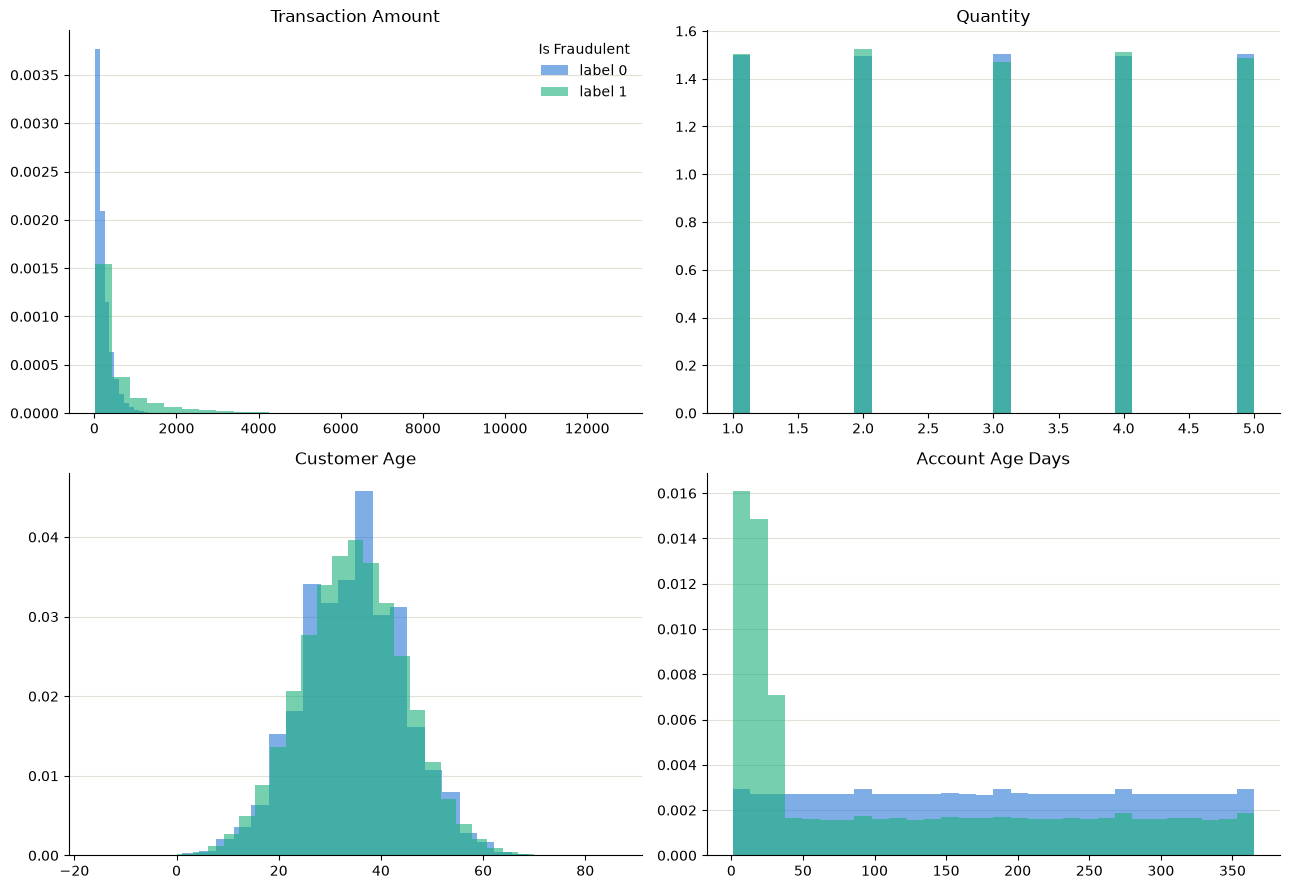

In [10]:
# 수치형 변수 분포 시각화 (Is Fraudulent별 비교, density 정규화)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flatten(), numeric_cols):
    for label_val, color in zip([0, 1], colors):
        subset = df.loc[df["Is Fraudulent"] == label_val, col]
        ax.hist(subset, bins=30, density=True, alpha=0.6, color=color, label=f"label {label_val}")

    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

axes.flatten()[0].legend(title="Is Fraudulent", frameon=False)
plt.tight_layout()
plt.show()


- Customer Age: 음수(-) 값이 있음
- Quantity: 사기인것과 아닌 것의 분포가 완전히 일치
- Account Age Days: 사기일 경우 초반에 몰려있음

In [11]:
# Customer Age 이상치(음수) 확인
df[df["Customer Age"] < 0][["Transaction ID", "Customer Age", "Is Fraudulent", "source_file"]]

# 음수 나이가 몇 건이나 되는지, 특정 source_file/라벨에 몰려있는지 확인
print("음수 나이 건수:", (df["Customer Age"] < 0).sum())
print(df[df["Customer Age"] < 0]["source_file"].value_counts())
print(df[df["Customer Age"] < 0]["Is Fraudulent"].value_counts())

음수 나이 건수: 259
source_file
Fraudulent_E-Commerce_Transaction_Data.csv      258
Fraudulent_E-Commerce_Transaction_Data_2.csv      1
Name: count, dtype: int64
Is Fraudulent
0    247
1     12
Name: count, dtype: int64


In [12]:
# 음수 나이의 절댓값 분포 확인 (부호 오류인지, 값 자체가 이상한지 판단)
df[df["Customer Age"] < 0]["Customer Age"].abs().describe()

count    259.000000
mean       3.127413
std        2.479994
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       16.000000
Name: Customer Age, dtype: float64

In [13]:
# 18세 미만 고객 비중 확인 (음수 나이 제거 이후 기준)
print("18세 미만 건수:", (df["Customer Age"] < 18).sum())
print(f"전체 대비 비중: {(df['Customer Age'] < 18).mean() * 100:.2f}%")
df[df["Customer Age"] < 18]["Is Fraudulent"].value_counts()

18세 미만 건수: 66526
전체 대비 비중: 4.45%


Is Fraudulent
0    63127
1     3399
Name: count, dtype: int64

In [14]:
# 중고거래 플랫폼(예: eBay) 이용 가능 연령 기준 - 18세 미만 제거
before = len(df)
df = df[df["Customer Age"] >= 18].reset_index(drop=True)
after = len(df)

print(f"{before}행 -> {after}행 ({before - after}건 제거)")

1496586행 -> 1430060행 (66526건 제거)


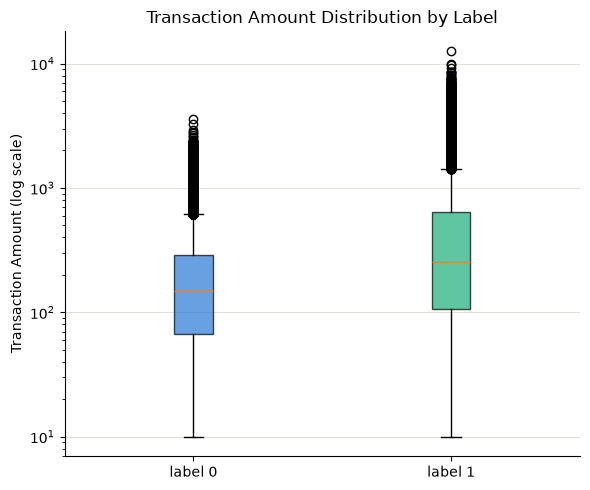

In [15]:
# Transaction Amount 분포 박스플롯 (라벨별 비교, 로그 스케일)
fig, ax = plt.subplots(figsize=(6, 5))
data = [df.loc[df["Is Fraudulent"] == lbl, "Transaction Amount"] for lbl in [0, 1]]
bp = ax.boxplot(data, patch_artist=True)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(["label 0", "label 1"])
ax.set_yscale("log")
ax.set_title("Transaction Amount Distribution by Label")
ax.set_ylabel("Transaction Amount (log scale)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [16]:
# IQR 기준 이상치 범위 계산
q1 = df["Transaction Amount"].quantile(0.25)
q3 = df["Transaction Amount"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"상한 기준(upper bound): {upper_bound:.2f}")
print(f"상한 초과 건수: {(df['Transaction Amount'] > upper_bound).sum()}건")

Q1: 68.62, Q3: 296.00, IQR: 227.38
상한 기준(upper bound): 637.07
상한 초과 건수: 76961건


In [17]:
# 이상치(상한 초과) 상세 내용 확인
outliers = df[df["Transaction Amount"] > upper_bound].sort_values("Transaction Amount", ascending=False)
print(outliers["Is Fraudulent"].value_counts())
outliers[["Transaction ID", "Transaction Amount", "Quantity", "Product Category", "Is Fraudulent"]].head(20)

Is Fraudulent
0    59096
1    17865
Name: count, dtype: int64


,Transaction ID,Transaction Amount,Quantity,Product Category,Is Fraudulent
807483,a7c9414c-647c-457a-97f5-aa875bb39093,12701.75,2,clothing,1
526786,2ad1bb33-473a-4881-b14d-8471991114cb,9990.90,4,electronics,1
1420629,6e97ba1f-2013-4c6e-a57c-d868c20ef291,9716.50,5,health & beauty,1
698870,091061e5-646f-4f55-b978-8fdfa1375eb9,9221.60,2,clothing,1
445152,f79f60c3-f788-486a-9ea0-5f1f43c99df6,8603.95,2,clothing,1
218132,d25ce7ed-9ee6-4b31-b752-3e904a6f0d0b,8594.90,5,clothing,1
819750,b1b9930f-fe23-4eb2-a6b4-69b020d298b8,8550.25,4,health & beauty,1
364986,23e55a9c-f2d4-4727-9c80-ff9f0ea83ecd,8329.90,1,toys & games,1
1210390,ae86756b-8d7e-4ee4-9630-f4d401361206,8105.15,3,toys & games,1
1297024,ddc291bb-3a2e-4fa7-8017-189bc4daabf4,8075.25,1,clothing,1


In [18]:
# Transaction Date 범위 확인 (이상한 날짜 있는지 체크)
print("최소:", df["Transaction Date"].min())
print("최대:", df["Transaction Date"].max())

최소: 2024-01-01 00:00:00
최대: 2024-04-07 08:54:03


In [20]:
# 날짜 관련 파생 변수 생성
df["trans_month"] = df["Transaction Date"].dt.month
df["trans_dayofweek"] = df["Transaction Date"].dt.dayofweek  # 0=월요일 ... 6=일요일
df["is_weekend"] = df["trans_dayofweek"].isin([5, 6]).astype(int)

# 월별 / 요일별 사기 비율 확인
month_fraud = df.groupby("trans_month")["Is Fraudulent"].mean() * 100
dow_fraud = df.groupby("trans_dayofweek")["Is Fraudulent"].mean() * 100
weekend_fraud = df.groupby("is_weekend")["Is Fraudulent"].mean() * 100

print(month_fraud)
print()
print(dow_fraud)
print()
print(weekend_fraud)

trans_month
1    5.006606
2    5.023074
3    4.999379
4    5.073823
Name: Is Fraudulent, dtype: float64

trans_dayofweek
0    5.074308
1    5.014623
2    4.962923
3    5.000201
4    4.995116
5    5.037571
6    4.989011
Name: Is Fraudulent, dtype: float64

is_weekend
0    5.010182
1    5.013284
Name: Is Fraudulent, dtype: float64


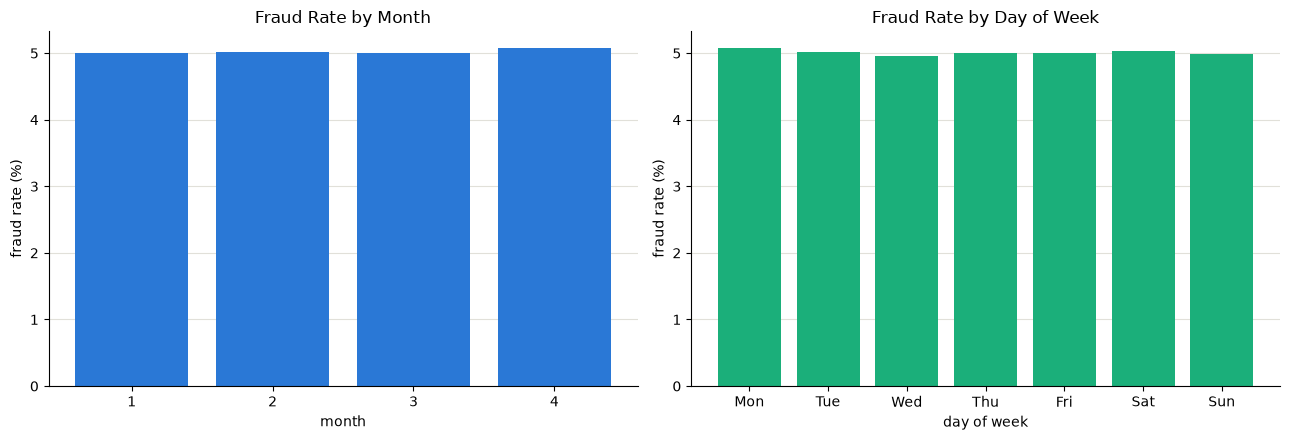

In [21]:
# 월별 / 요일별 사기 비율 시각화
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(month_fraud.index.astype(str), month_fraud.values, color="#2a78d6")
axes[0].set_title("Fraud Rate by Month")
axes[0].set_xlabel("month")
axes[0].set_ylabel("fraud rate (%)")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
axes[0].set_axisbelow(True)

axes[1].bar(dow_labels, dow_fraud.values, color="#1baf7a")
axes[1].set_title("Fraud Rate by Day of Week")
axes[1].set_xlabel("day of week")
axes[1].set_ylabel("fraud rate (%)")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

In [22]:
# 카테고리형 변수(Product Category) 분포 및 사기 비율 확인
df["Product Category"].value_counts()

Product Category
health & beauty    286760
electronics        286661
clothing           285778
toys & games       285527
home & garden      285334
Name: count, dtype: int64

In [23]:
# Product Category별 사기 비율 확인
cat_fraud = df.groupby("Product Category")["Is Fraudulent"].mean().mul(100).sort_values(ascending=False)
cat_fraud

Product Category
clothing           5.043425
toys & games       5.038052
home & garden      5.020082
health & beauty    5.004882
electronics        4.949051
Name: Is Fraudulent, dtype: float64

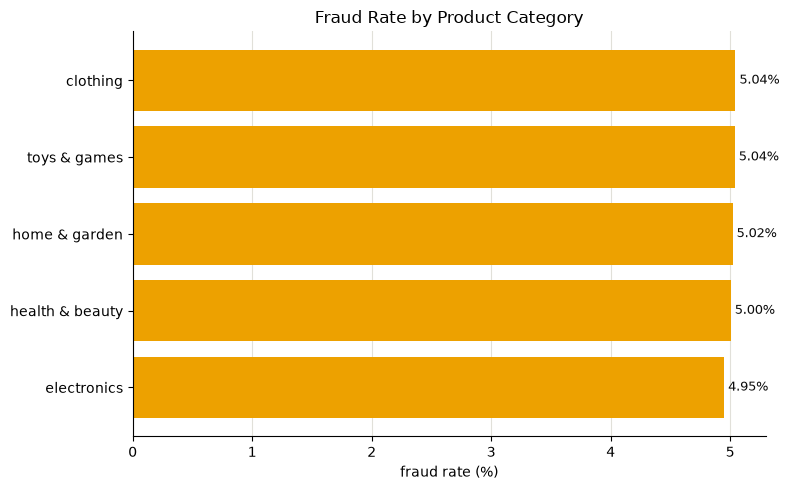

In [24]:
# Product Category별 사기 비율 시각화
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cat_fraud.index[::-1], cat_fraud.values[::-1], color="#eda100")

for i, v in enumerate(cat_fraud.values[::-1]):
    ax.text(v, i, f" {v:.2f}%", va="center", fontsize=9, color="#0b0b0b")

ax.set_title("Fraud Rate by Product Category")
ax.set_xlabel("fraud rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [25]:
# 수치형 피처 상관관계 분석 (Is Fraudulent 포함)
corr_cols = [
    "Transaction Amount", "Quantity", "Customer Age", "Account Age Days",
    "trans_month", "trans_dayofweek", "is_weekend", "Is Fraudulent",
]

corr = df[corr_cols].corr()
corr

,Transaction Amount,Quantity,Customer Age,Account Age Days,trans_month,trans_dayofweek,is_weekend,Is Fraudulent
Transaction Amount,1.000000,-0.000485,0.000408,-0.035838,-0.000187,-0.000920,-0.000285,0.272774
Quantity,-0.000485,1.000000,0.000418,0.001143,-0.001139,0.001044,0.000329,-0.000891
Customer Age,0.000408,0.000418,1.000000,-0.000158,-0.000940,-0.000329,-0.000060,-0.000787
Account Age Days,-0.035838,0.001143,-0.000158,1.000000,-0.000061,0.000506,-0.000197,-0.136308
trans_month,-0.000187,-0.001139,-0.000940,-0.000061,1.000000,0.010517,0.018878,0.000043
trans_dayofweek,-0.000920,0.001044,-0.000329,0.000506,0.010517,1.000000,0.790782,-0.000606
is_weekend,-0.000285,0.000329,-0.000060,-0.000197,0.018878,0.790782,1.000000,0.000064
Is Fraudulent,0.272774,-0.000891,-0.000787,-0.136308,0.000043,-0.000606,0.000064,1.000000


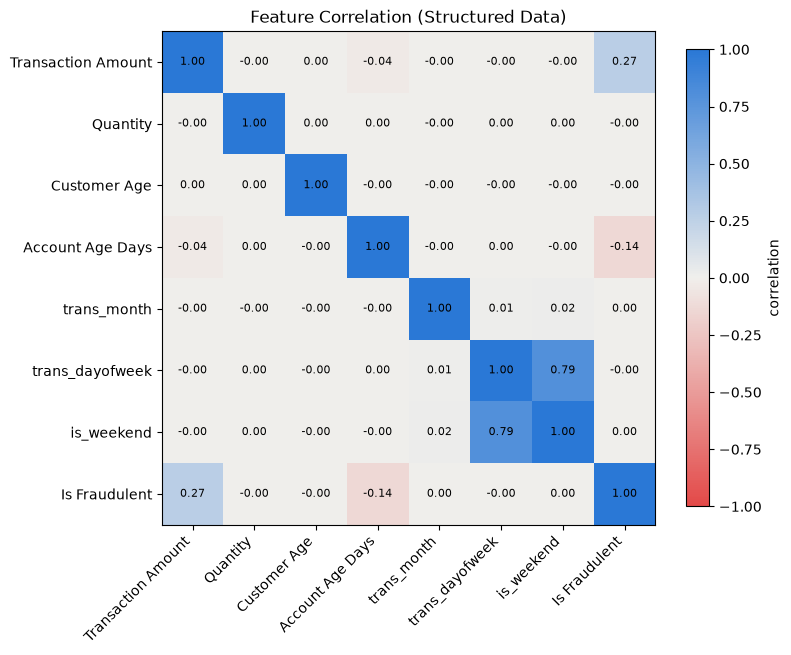

In [26]:
# 상관관계 히트맵 시각화 (diverging: 파랑=양의 상관, 빨강=음의 상관, 회색=0)
from matplotlib.colors import LinearSegmentedColormap

diverging_cmap = LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Feature Correlation (Structured Data)")
plt.tight_layout()
plt.show()

- Transaction Amount: 가장 중요 변수(약한 양의 상관관계)
- Account Age Days: 계정이 오래될수록 사기 확률이 낮음

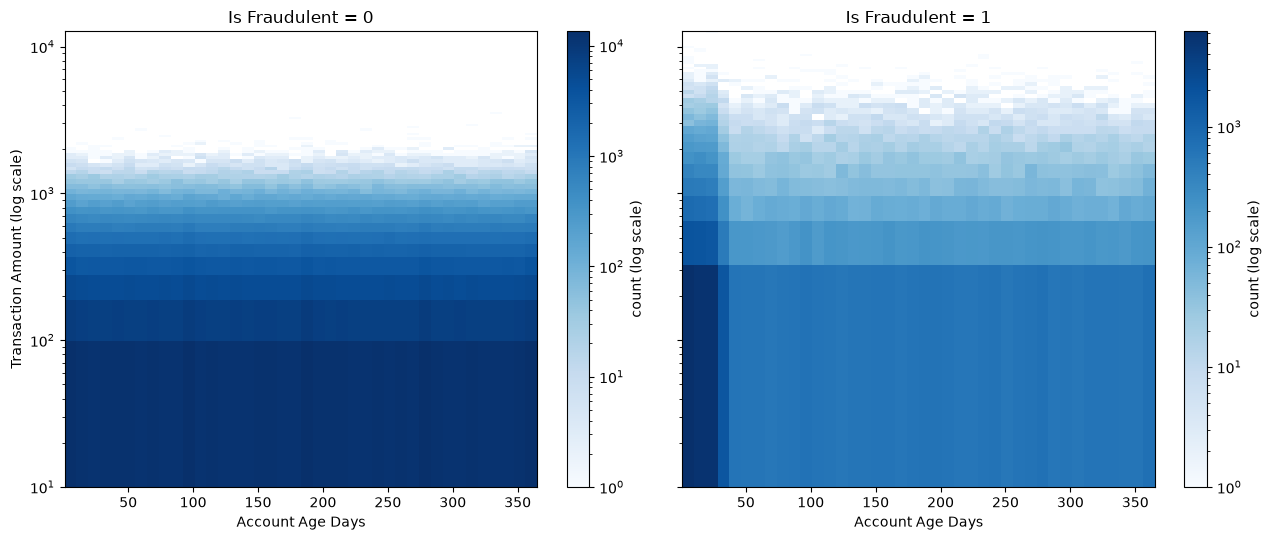

In [27]:
# Transaction Amount x Account Age Days 관계를 라벨별로 시각화 (2D 히스토그램, 두 피처의 상호작용 확인)
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

for ax, label_val in zip(axes, [0, 1]):
    subset = df[df["Is Fraudulent"] == label_val]
    h = ax.hist2d(
        subset["Account Age Days"], subset["Transaction Amount"],
        bins=40, cmap="Blues", norm=plt.matplotlib.colors.LogNorm(),
    )
    ax.set_title(f"Is Fraudulent = {label_val}")
    ax.set_xlabel("Account Age Days")
    ax.set_yscale("log")
    fig.colorbar(h[3], ax=ax, label="count (log scale)")

axes[0].set_ylabel("Transaction Amount (log scale)")
plt.tight_layout()
plt.show()

In [28]:
# Customer ID 반복 여부 확인
print("전체 행 수:", len(df))
print("고유 Customer ID 수:", df["Customer ID"].nunique())
print("반복 거래가 있는 고객 수:", (df["Customer ID"].value_counts() > 1).sum())

전체 행 수: 1430060
고유 Customer ID 수: 1430060
반복 거래가 있는 고객 수: 0


In [30]:
# Shipping Address 반복 여부 확인 (같은 주소로 여러 계정이 받는 경우 - 대표적인 사기 패턴)
print("전체 행 수:", len(df))
print("고유 Shipping Address 수:", df["Shipping Address"].nunique())

shipping_count = df["Shipping Address"].value_counts()
print("2회 이상 반복 사용된 주소 수:", (shipping_count > 1).sum())
shipping_count.describe()

전체 행 수: 1430060
고유 Shipping Address 수: 1430056
2회 이상 반복 사용된 주소 수: 4


count    1.430056e+06
mean     1.000003e+00
std      1.672450e-03
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.000000e+00
Name: count, dtype: float64

In [31]:
# 주소 반복 횟수를 df에 매핑 후, 사기 여부와의 관계 확인
df["shipping_addr_count"] = df["Shipping Address"].map(shipping_count)

df.groupby("shipping_addr_count")["Is Fraudulent"].mean().mul(100).head(20)

shipping_addr_count
1    5.011077
2    0.000000
Name: Is Fraudulent, dtype: float64

In [35]:
# Shipping Address 마지막 줄에서 주(state) 코드 추출 (일반 주소 "City, ST ZIP" / 군사 주소 "APO/DPO ST ZIP" 모두 대응)
df["shipping_state"] = df["Shipping Address"].str.split("\n").str[-1].str.extract(r"([A-Z]{2})\s+\d{5}")

print("추출 실패(결측) 건수:", df["shipping_state"].isnull().sum())
df["shipping_state"].value_counts().head(20)

추출 실패(결측) 건수: 0


shipping_state
AE    51232
AA    51208
AP    50644
MT    21960
WA    21911
ME    21886
MP    21863
MI    21854
NV    21825
KY    21803
WY    21801
AZ    21799
PA    21773
MA    21772
CO    21765
WV    21756
NC    21755
UT    21745
MD    21736
PR    21736
Name: count, dtype: int64

In [36]:
# 주(state)별 사기 비율 확인 (거래 건수가 너무 적은 주는 제외하고 신뢰도 있는 것만)
state_stats = df.groupby("shipping_state")["Is Fraudulent"].agg(["mean", "count"])
state_stats["fraud_rate(%)"] = state_stats["mean"] * 100
state_stats = state_stats[state_stats["count"] >= 100].sort_values("fraud_rate(%)", ascending=False)

state_stats.head(20)

,mean,count,fraud_rate(%)
shipping_state,,,
NJ,0.052441,21510,5.244073
HI,0.052208,21510,5.220828
AR,0.052078,21583,5.207802
SD,0.052041,21560,5.204082
NY,0.051534,21714,5.153357
CO,0.051413,21765,5.141282
MN,0.051390,21658,5.138979
DE,0.051386,21173,5.138620
WY,0.051374,21801,5.137379


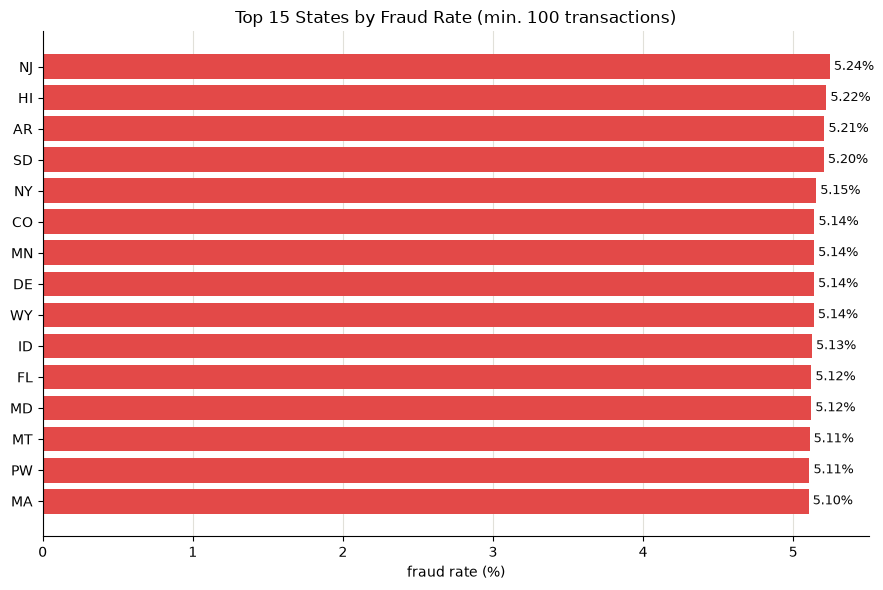

In [37]:
# 상위/하위 주(state) 사기 비율 시각화
top15 = state_stats.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index[::-1], top15["fraud_rate(%)"].values[::-1], color="#e34948")

for i, v in enumerate(top15["fraud_rate(%)"].values[::-1]):
    ax.text(v, i, f" {v:.2f}%", va="center", fontsize=9, color="#0b0b0b")

ax.set_title("Top 15 States by Fraud Rate (min. 100 transactions)")
ax.set_xlabel("fraud rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [41]:
# 최종 정제된 정형 데이터셋 저장
output_path = Path("/Users/junyup/Desktop/workspace/SafeTrader_Detection/datasets/Fraudulent_E-Commerce_Transaction_Data_cleaned.csv")

drop_derived_cols = [
    "shipping_addr_bin", "is_weekend",
    "shipping_addr_count", "customer_txn_count",
    "source_file", "Transaction ID", "Customer ID",
    "Shipping Address",
]
df_final = df.drop(columns=drop_derived_cols, errors="ignore")
df_final.to_csv(output_path, index=False)

print(f"저장 완료: {output_path} ({len(df_final)}행, {len(df_final.columns)}열)")
df_final.columns.tolist()

저장 완료: /Users/junyup/Desktop/workspace/SafeTrader_Detection/datasets/Fraudulent_E-Commerce_Transaction_Data_cleaned.csv (1430060행, 10열)


['Transaction Amount',
 'Transaction Date',
 'Product Category',
 'Quantity',
 'Customer Age',
 'Is Fraudulent',
 'Account Age Days',
 'trans_month',
 'trans_dayofweek',
 'shipping_state']